## Introduction to Pandas

#### **Name:Manuel Ibañez Salazar** <Insert Name>

#### Import Pandas

In [2]:
import pandas as pd

#### Creating Series

In [3]:
import pandas as pd

serie = pd.Series([10, 20, 30, 40, 50])
print("Serie simple:\n", serie)


Serie simple:
 0    10
1    20
2    30
3    40
4    50
dtype: int64


#### Viewing Data

In [4]:
import pandas as pd
serie = pd.Series(
    data=[10, 20, 30, 40, 50],
    index=["A", "B", "C", "D", "E"],
    name="Mi_Serie"
)

In [19]:
df = pd.DataFrame({
    "Nombre": ["Manuel", "Jaz", "Gaby"],
    "Edad": [28, 25, 26],
    "Ciudad": ["Tepic", "Mexico", "Nayarit"]
})

In [20]:
df["Nombre"] 
df[["Nombre", "Edad"]] 

,Nombre,Edad
0,Manuel,28
1,Jaz,25
2,Gaby,26


In [21]:
df[df["Edad"] > 25]

,Nombre,Edad,Ciudad
0,Manuel,28,Tepic
2,Gaby,26,Nayarit


In [22]:
pd.set_option("display.max_columns", None)

In [1]:
import pandas as pd

df = pd.DataFrame({
    "Nombre": ["Gaby", "Manuel", "Jaz"],
    "Edad": [25, 30, 22],
    "Ciudad": ["Tepic", "Monterrey", "Guadalajara"]
})

print("\nAlternativa 1 - Formato básico:")
print(df.to_string(index=False))

print("\nAlternativa 2 - Markdown manual:")
print("| " + " | ".join(df.columns) + " |")
print("|" + "|".join(["---"]*len(df.columns)) + "|")
for _, row in df.iterrows():
    print("| " + " | ".join(str(x) for x in row) + " |")



Alternativa 1 - Formato básico:
Nombre  Edad      Ciudad
  Gaby    25       Tepic
Manuel    30   Monterrey
   Jaz    22 Guadalajara

Alternativa 2 - Markdown manual:
| Nombre | Edad | Ciudad |
|---|---|---|
| Gaby | 25 | Tepic |
| Manuel | 30 | Monterrey |
| Jaz | 22 | Guadalajara |


#### Describe data

 DATOS DE EJEMPLO (primeras filas):
   Edad  Ingresos  Genero   Educacion  Satisfaccion  Activo
0    39        30   Mujer  Secundaria             2    True
1    33        46   Mujer    Primaria             8    True
2    41        47  Hombre    Primaria             4    True
3    50        39  Hombre  Secundaria             9    True
4    32        51  Hombre    Posgrado             5    True

 ANÁLISIS DESCRIPTIVO COMPLETO

 INFORMACIÓN BÁSICA:
- Total de registros: 100
- Variables/columnas: 6
- Memoria usada: 3.74 KB

 ESTADÍSTICAS NUMÉRICAS:
             Edad    Ingresos  Satisfaccion
count  100.000000  100.000000     100.00000
mean    33.420000   58.860000       5.72000
std      9.130015   25.207831       2.88878
min      8.000000   25.000000       1.00000
1%      14.930000   27.970000       1.00000
5%      17.000000   30.950000       1.00000
25%     28.000000   39.000000       3.00000
50%     33.000000   56.000000       5.50000
75%     38.250000   67.500000       8.25000
95%     4

<Figure size 1200x600 with 0 Axes>

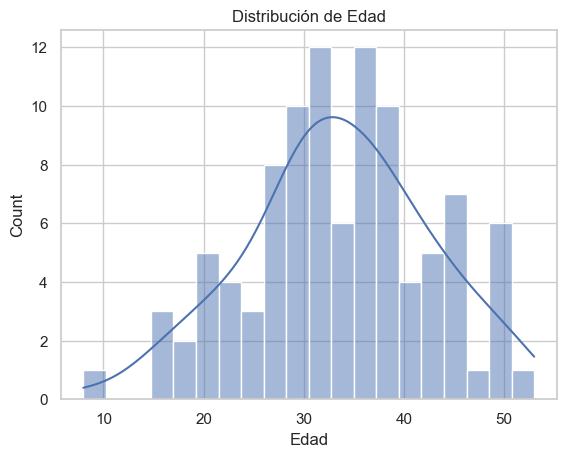

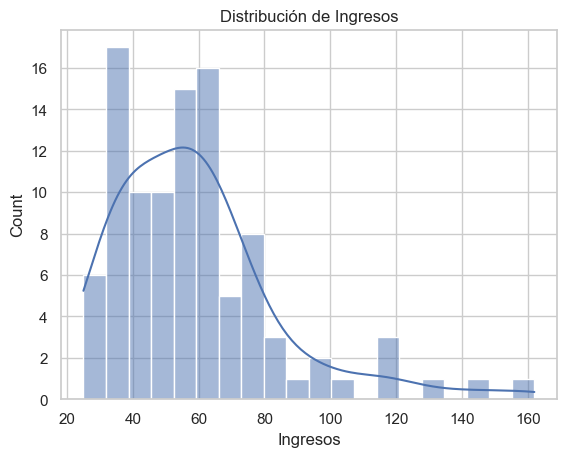

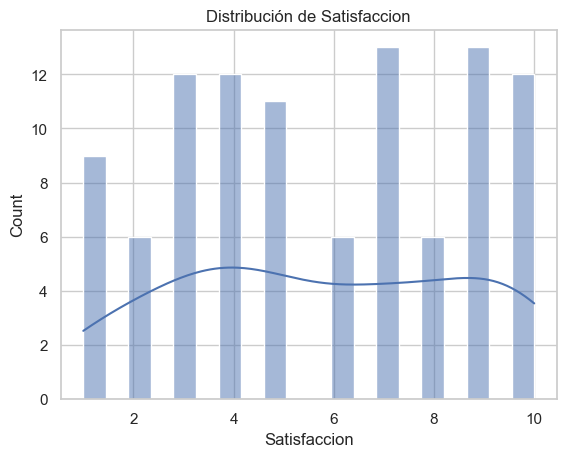

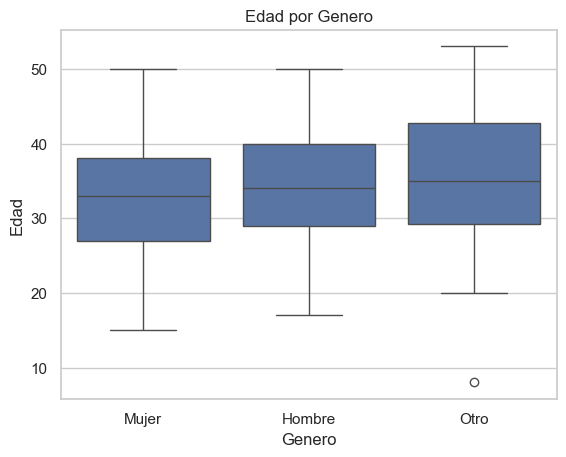

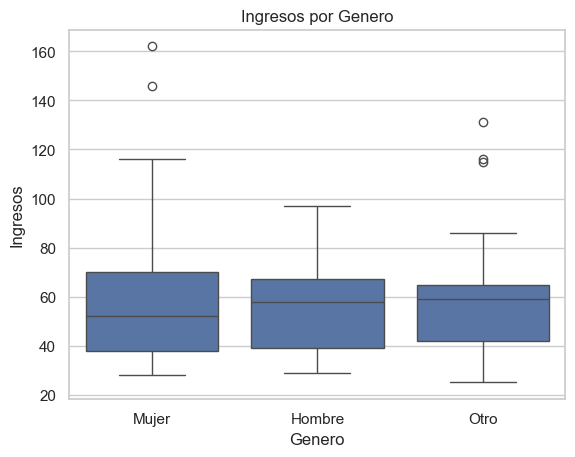

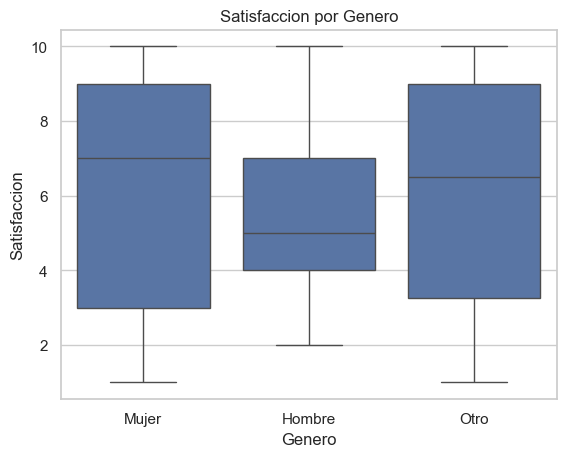

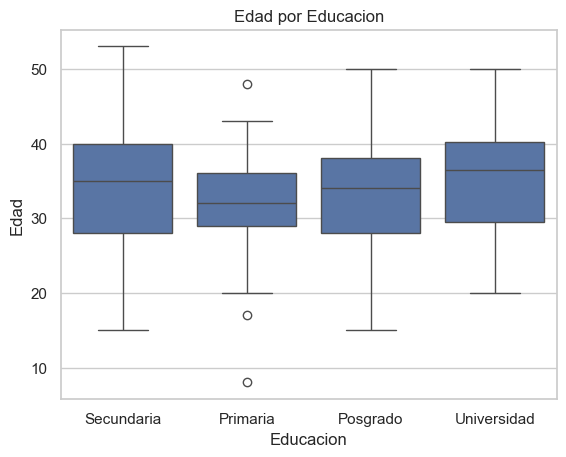

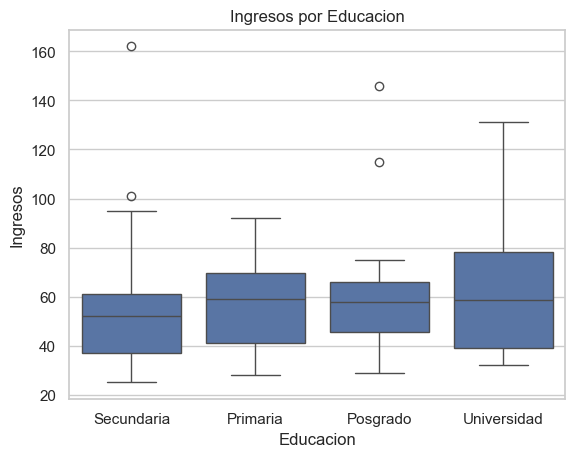

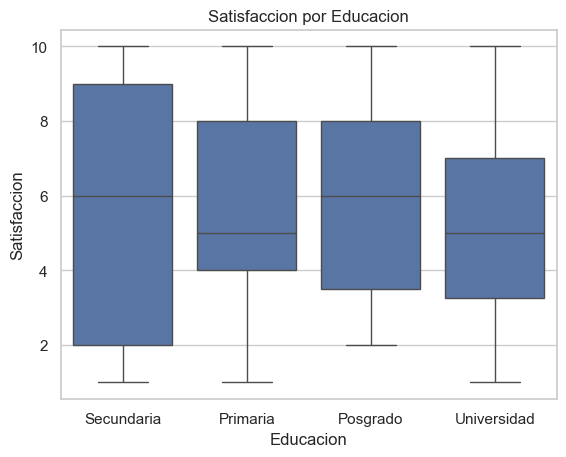

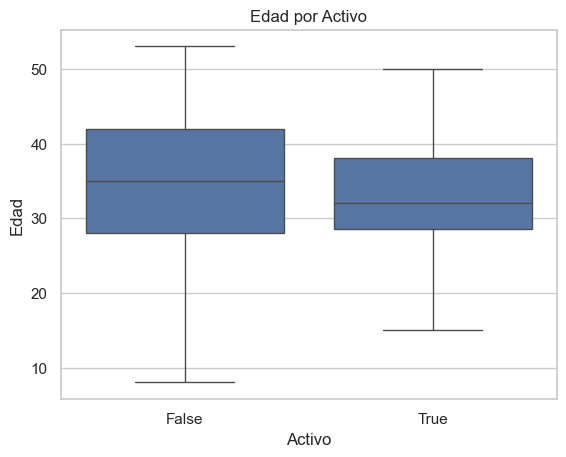

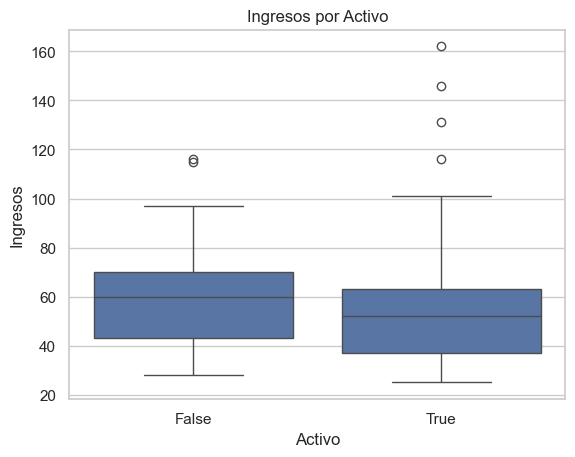

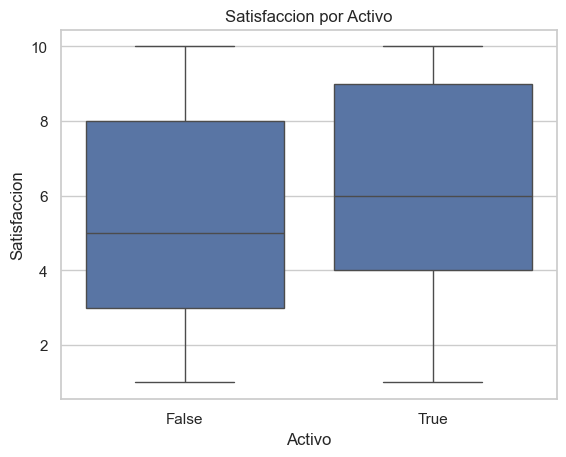

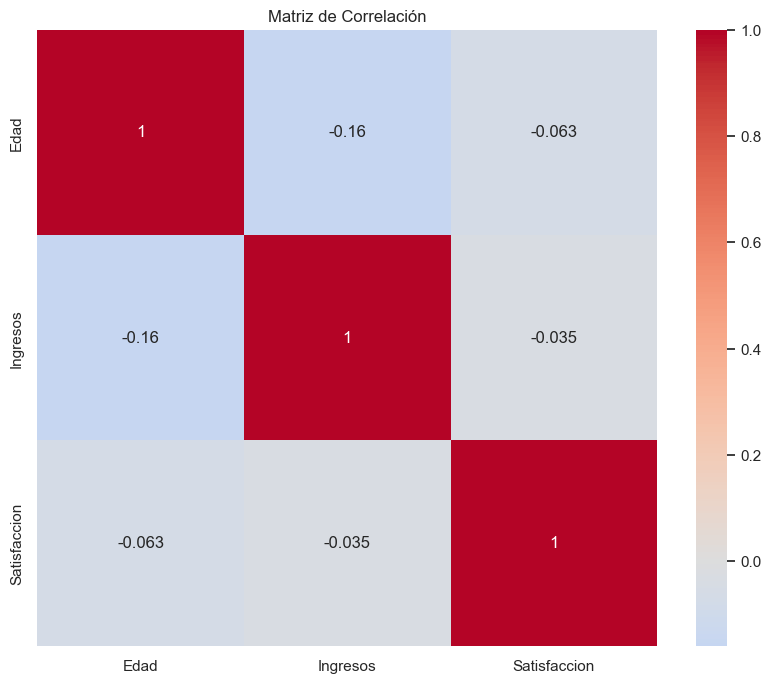

In [ ]:
import pandas as pd
import numpy as np


np.random.seed(42)  
data = {
    'Edad': np.random.normal(35, 10, 100).astype(int),
    'Ingresos': np.random.lognormal(4, 0.4, 100).astype(int),
    'Genero': np.random.choice(['Hombre', 'Mujer', 'Otro'], 100),
    'Educacion': np.random.choice(['Primaria', 'Secundaria', 'Universidad', 'Doctorado'], 100),
    'Satisfaccion': np.random.randint(1, 11, 100),
    'Activo': np.random.choice([True, False], 100)
}
df = pd.DataFrame(data)

df['Edad'] = df['Edad'].abs()

def describe_data(dataframe):
    """
    Realiza un análisis descriptivo completo de un DataFrame
    incluyendo estadísticas, valores faltantes y distribuciones
    """
    print("\n" + "="*50)
    print(" ANÁLISIS DESCRIPTIVO COMPLETO")
    print("="*50 + "\n")
    
    
    print(" INFORMACIÓN BÁSICA:")
    print(f"- Total de registros: {len(dataframe)}")
    print(f"- Variables/columnas: {len(dataframe.columns)}")
    print(f"- Memoria usada: {dataframe.memory_usage().sum()/1024:.2f} KB\n")
    
    
    print(" ESTADÍSTICAS NUMÉRICAS:")
    print(dataframe.describe(percentiles=[.01, .05, .25, .5, .75, .95, .99]).to_string())
    
    
    categorical = dataframe.select_dtypes(include=['object', 'bool'])
    if not categorical.empty:
        print("\n ESTADÍSTICAS CATEGÓRICAS:")
        for col in categorical:
            print(f"\nVariable: {col}")
            print(dataframe[col].value_counts(dropna=False).to_string())
    
    
    print("\n VALORES FALTANTES:")
    missing = dataframe.isnull().sum().to_frame('Faltantes')
    missing['%'] = (missing['Faltantes']/len(dataframe)*100).round(2)
    print(missing.to_string())
    
   
    if len(categorical.columns) > 0:
        print("\n ANÁLISIS POR GRUPOS:")
        for cat_col in categorical:
            if len(dataframe[cat_col].unique()) > 1:  
                print(f"\n► Por {cat_col}:")
                print(dataframe.groupby(cat_col).agg({
                    'Edad': ['mean', 'std', 'count'],
                    'Ingresos': ['median', 'mean', 'std']
                }).round(2).to_string())
    

    numeric_cols = dataframe.select_dtypes(include=np.number).columns
    if len(numeric_cols) > 1:
        print("\n MATRIZ DE CORRELACIONES:")
        print(dataframe[numeric_cols].corr().round(2).to_string())

def visualize_data(dataframe):
    """
    Genera visualizaciones básicas de los datos
    Requiere matplotlib y seaborn instalados
    """
    try:
        import matplotlib.pyplot as plt
        import seaborn as sns
        
        print("\n" + "="*50)
        print(" VISUALIZACIONES DE DATOS")
        print("="*50 + "\n")
        
        
        sns.set(style="whitegrid")
        plt.figure(figsize=(12, 6))
        
    
        numeric_cols = dataframe.select_dtypes(include=np.number).columns
        for col in numeric_cols:
            plt.figure()
            sns.histplot(data=dataframe, x=col, kde=True, bins=20)
            plt.title(f'Distribución de {col}')
            plt.show()
        
       
        categorical = dataframe.select_dtypes(include=['object', 'bool'])
        if len(categorical.columns) > 0 and len(numeric_cols) > 0:
            for cat_col in categorical:
                if len(dataframe[cat_col].unique()) <= 5:  
                    for num_col in numeric_cols:
                        plt.figure()
                        sns.boxplot(data=dataframe, x=cat_col, y=num_col)
                        plt.title(f'{num_col} por {cat_col}')
                        plt.show()

        if len(numeric_cols) > 1:
            plt.figure(figsize=(10, 8))
            sns.heatmap(dataframe[numeric_cols].corr(), annot=True, cmap='coolwarm', center=0)
            plt.title('Matriz de Correlación')
            plt.show()
            
    except ImportError:
        print("\nℹ Para visualizaciones, instala matplotlib y seaborn:")
        print("pip install matplotlib seaborn")


if __name__ == "__main__":

    print(" DATOS DE EJEMPLO (primeras filas):")
    print(df.head(5).to_string())
    describe_data(df)
    visualize_data(df)

#### Filtering Data

In [ ]:
import pandas as pd
import numpy as np

data = {
    'Nombre': ['Gaby', 'Carlitos', 'Pancho', 'Angel', 'Ramos', 'Jaz'],
    'Edad': [25, 32, 18, 47, 22, 35],
    'Ciudad': ['Tepic', 'Cancun', 'Monterrey', 'Guadalajara', 'Chetumal', 'Pto Vallarta'],
    'Salario': [32000, 45000, 22000, 70000, 28000, 55000],
    'Departamento': ['Ventas', 'TI', 'Ventas', 'Dirección', 'Marketing', 'TI']
}
df = pd.DataFrame(data)

print(" DATOS ORIGINALES:")
print(df.to_markdown(tablefmt="grid", stralign="left"))


print("\n" + "="*50)
print(" FILTRADO BÁSICO")
print("="*50)


mayores_30 = df[df['Edad'] > 30]
print("\n Personas mayores de 30 años:")
print(mayores_30.to_markdown(tablefmt="grid"))


ventas_madrid = df[(df['Departamento'] == 'Ventas') & (df['Ciudad'] == 'Madrid')]
print("\n Vendedores en Madrid:")
print(ventas_madrid.to_markdown(tablefmt="grid"))


marketing_o_ti = df[df['Departamento'].isin(['Marketing', 'TI'])]
print("\n Departamento de Marketing o TI:")
print(marketing_o_ti.to_markdown(tablefmt="grid"))

print("\n" + "="*50)
print(" FILTRADO AVANZADO")
print("="*50)

contiene_a = df[df['Nombre'].str.contains('a', case=False)]
print("\n Nombres que contienen 'a':")
print(contiene_a.to_markdown(tablefmt="grid"))

salario_medio = df[df['Salario'].between(30000, 60000)]
print("\n Salarios entre 30K y 60K:")
print(salario_medio.to_markdown(tablefmt="grid"))


alta_dir = df.query("Salario > 50000 and Departamento == 'Dirección'")
print("\n Alta dirección:")
print(alta_dir.to_markdown(tablefmt="grid"))


print("\n" + "="*50)
print(" FILTRADO POR GRUPOS")
print("="*50)

top_salarios = df.sort_values('Salario', ascending=False).groupby('Departamento').head(2)
print("\n Top 2 salarios por departamento:")
print(top_salarios.to_markdown(tablefmt="grid"))


def filtrar_grupo(grupo):
    return grupo[grupo['Salario'] > grupo['Salario'].mean()]

empleados_sobre_media = df.groupby('Departamento').apply(filtrar_grupo)
print("\n Empleados con salario sobre la media de su departamento:")
print(empleados_sobre_media.to_markdown(tablefmt="grid"))

print("\n" + "="*50)
print(" FILTRADO POR POSICIÓN/ETIQUETA")
print("="*50)


filtro_loc = df.loc[df['Edad'] > 25, ['Nombre', 'Ciudad', 'Salario']]
print("\n LOC: Filas con edad >25 y columnas específicas:")
print(filtro_loc.to_markdown(tablefmt="grid"))


filtro_iloc = df.iloc[1:4, [0, 2, 3]]  
print("\n ILOC: Por posición numérica:")
print(filtro_iloc.to_markdown(tablefmt="grid"))
df_con_nulos = df.copy()
df_con_nulos.loc[2:3, 'Salario'] = np.nan

print("\n" + "="*50)
print(" FILTRADO DE VALORES NULOS")
print("="*50)


sin_nulos = df_con_nulos.dropna()
print("\n Filas completas sin valores nulos:")
print(sin_nulos.to_markdown(tablefmt="grid"))


con_nulos = df_con_nulos[df_con_nulos.isnull().any(axis=1)]
print("\n Filas con valores nulos:")
print(con_nulos.to_markdown(tablefmt="grid"))

📋 DATOS ORIGINALES:
+----+----------+--------+--------------+-----------+----------------+
|    | Nombre   |   Edad | Ciudad       |   Salario | Departamento   |
+====+==========+========+==============+===========+================+
|  0 | Gaby     |     25 | Tepic        |     32000 | Ventas         |
+----+----------+--------+--------------+-----------+----------------+
|  1 | Carlitos |     32 | Cancun       |     45000 | TI             |
+----+----------+--------+--------------+-----------+----------------+
|  2 | Pancho   |     18 | Monterrey    |     22000 | Ventas         |
+----+----------+--------+--------------+-----------+----------------+
|  3 | Angel    |     47 | Guadalajara  |     70000 | Dirección      |
+----+----------+--------+--------------+-----------+----------------+
|  4 | Ramos    |     22 | Chetumal     |     28000 | Marketing      |
+----+----------+--------+--------------+-----------+----------------+
|  5 | Jaz      |     35 | Pto Vallarta |     55000 | TI 

C:\Users\manue\AppData\Local\Temp\ipykernel_1088\3861218030.py:66: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  empleados_sobre_media = df.groupby('Departamento').apply(filtrar_grupo)


#### Dataframe Indexing

In [ ]:
import pandas as pd
import numpy as np

data = {
    'Nombre': ['Ana', 'Luis', 'Carlos', 'María', 'Pedro', 'Laura'],
    'Edad': [25, 32, 18, 47, 22, 35],
    'Ciudad': ['Madrid', 'Barcelona', 'Valencia', 'Madrid', 'Sevilla', 'Barcelona'],
    'Salario': [32000, 45000, 22000, 70000, 28000, 55000],
    'Departamento': ['Ventas', 'TI', 'Ventas', 'Dirección', 'Marketing', 'TI']
}

df_default = pd.DataFrame(data)

df_nombre_index = pd.DataFrame(data).set_index('Nombre')

print("=== DATAFRAMES INICIALES ===")
print("\n1. DataFrame con índice numérico:")
print(df_default.to_markdown(tablefmt="grid"))

print("\n2. DataFrame con 'Nombre' como índice:")
print(df_nombre_index.to_markdown(tablefmt="grid"))


print("\n🔹 Acceso a columnas:")
print(df_default['Ciudad'].to_markdown(tablefmt="grid"))  
print(df_default[['Nombre', 'Salario']].head(3).to_markdown(tablefmt="grid"))  

print("\n🔹 loc - Indexación por etiqueta:")
print("Fila 2 completa:")
print(df_default.loc[2].to_markdown(tablefmt="grid"))  

print("\nRango de filas y columnas específicas:")
print(df_default.loc[1:3, ['Nombre', 'Departamento']].to_markdown(tablefmt="grid"))

print("\nCon índice de nombres (María y Pedro):")
print(df_nombre_index.loc[['María', 'Pedro'], ['Edad', 'Salario']].to_markdown(tablefmt="grid"))

print("\n🔹 iloc - Indexación por posición:")
print("Fila en posición 1, columnas 0 a 2:")
print(df_default.iloc[1, 0:3].to_markdown(tablefmt="grid"))

print("\nFilas 1 a 3, columnas alternas:")
print(df_default.iloc[1:4, ::2].to_markdown(tablefmt="grid"))

print("\n🔹 Acceso rápido a valores:")
print("Valor específico con at (María, Salario):", df_nombre_index.at['María', 'Salario'])
print("Valor específico con iat (fila 2, col 3):", df_default.iat[2, 3])



print("\n🔹 Indexación booleana:")
print("Empleados en Madrid con salario > 30K:")
condicion = (df_default['Ciudad'] == 'Madrid') & (df_default['Salario'] > 30000)
print(df_default[condicion].to_markdown(tablefmt="grid"))


print("\n🔹 Indexación con query():")
print("Empleados de TI menores de 40 años:")
print(df_default.query("Departamento == 'TI' and Edad < 40").to_markdown(tablefmt="grid"))


print("\n🔹 Multi-índices:")
df_multiindex = df_default.set_index(['Departamento', 'Nombre'])
print(df_multiindex.sort_index().head().to_markdown(tablefmt="grid"))

print("\nAcceso a grupo 'Ventas':")
print(df_multiindex.loc['Ventas'].to_markdown(tablefmt="grid"))



print("\n Resetear índice:")
print(df_nombre_index.reset_index().head().to_markdown(tablefmt="grid"))


print("\n Ordenar por índice (descendente):")
print(df_nombre_index.sort_index(ascending=False).head().to_markdown(tablefmt="grid"))


print("\n Operaciones con índices:")
print("Índices existentes:", df_nombre_index.index.values)
print("¿Está 'Carlos' en el índice?", 'Carlos' in df_nombre_index.index)

=== DATAFRAMES INICIALES ===

1. DataFrame con índice numérico:
+----+----------+--------+-----------+-----------+----------------+
|    | Nombre   |   Edad | Ciudad    |   Salario | Departamento   |
+====+==========+========+===========+===========+================+
|  0 | Ana      |     25 | Madrid    |     32000 | Ventas         |
+----+----------+--------+-----------+-----------+----------------+
|  1 | Luis     |     32 | Barcelona |     45000 | TI             |
+----+----------+--------+-----------+-----------+----------------+
|  2 | Carlos   |     18 | Valencia  |     22000 | Ventas         |
+----+----------+--------+-----------+-----------+----------------+
|  3 | María    |     47 | Madrid    |     70000 | Dirección      |
+----+----------+--------+-----------+-----------+----------------+
|  4 | Pedro    |     22 | Sevilla   |     28000 | Marketing      |
+----+----------+--------+-----------+-----------+----------------+
|  5 | Laura    |     35 | Barcelona |     55000 | T

#### Loading a Dataset
![image.png](iris_species.png)

=== PRIMERAS FILAS DEL DATASET ===
+----+---------------------+--------------------+---------------------+--------------------+-----------+
|    |   sepal length (cm) |   sepal width (cm) |   petal length (cm) |   petal width (cm) | species   |
+====+=====================+====================+=====================+====================+===========+
|  0 |                 5.1 |                3.5 |                 1.4 |                0.2 | setosa    |
+----+---------------------+--------------------+---------------------+--------------------+-----------+
|  1 |                 4.9 |                3   |                 1.4 |                0.2 | setosa    |
+----+---------------------+--------------------+---------------------+--------------------+-----------+
|  2 |                 4.7 |                3.2 |                 1.3 |                0.2 | setosa    |
+----+---------------------+--------------------+---------------------+--------------------+-----------+
|  3 |              

<Figure size 1500x1000 with 0 Axes>

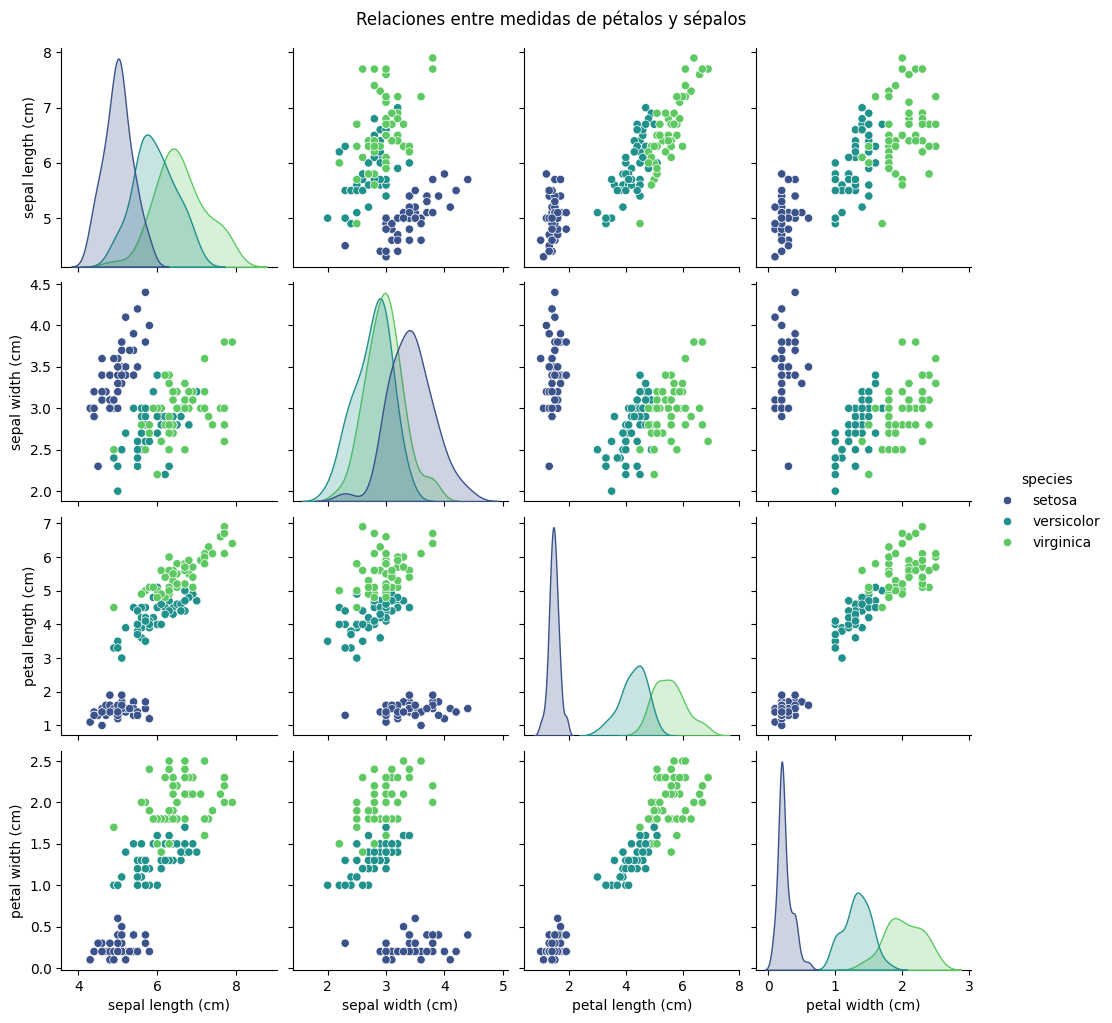


Generando boxplots comparativos...


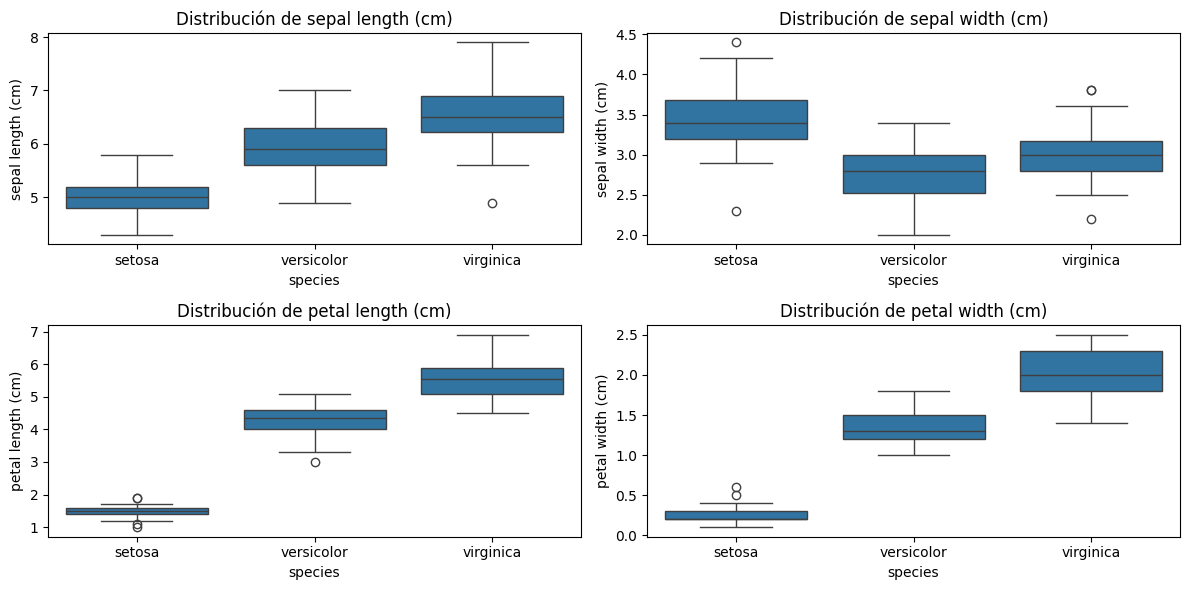


=== MEDIAS POR ESPECIE ===
+------------+---------------------+--------------------+---------------------+--------------------+
| species    |   sepal length (cm) |   sepal width (cm) |   petal length (cm) |   petal width (cm) |
+============+=====================+====================+=====================+====================+
| setosa     |               5.006 |              3.428 |               1.462 |              0.246 |
+------------+---------------------+--------------------+---------------------+--------------------+
| versicolor |               5.936 |              2.77  |               4.26  |              1.326 |
+------------+---------------------+--------------------+---------------------+--------------------+
| virginica  |               6.588 |              2.974 |               5.552 |              2.026 |
+------------+---------------------+--------------------+---------------------+--------------------+


C:\Users\manue\AppData\Local\Temp\ipykernel_9044\2045349961.py:42: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df.groupby('species').mean().to_markdown(tablefmt="grid"))



=== DIVISIÓN TRAIN/TEST ===
Entrenamiento: 105 muestras
Prueba: 45 muestras


In [1]:
import pandas as pd
from sklearn.datasets import load_iris
import matplotlib.pyplot as plt
import seaborn as sns


iris = load_iris()
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df['species'] = pd.Categorical.from_codes(iris.target, iris.target_names)

print("=== PRIMERAS FILAS DEL DATASET ===")
print(df.head().to_markdown(tablefmt="grid"))

print("\n=== INFORMACIÓN BÁSICA ===")
print(f"Total de muestras: {len(df)}")
print(f"Variables: {iris.feature_names}")
print(f"Especies: {iris.target_names}\n")

print("=== ESTADÍSTICAS DESCRIPTIVAS ===")
print(df.describe().to_markdown(tablefmt="grid"))


plt.figure(figsize=(15, 10))


print("\nGenerando gráficos de relación entre variables...")
sns.pairplot(df, hue='species', palette='viridis')
plt.suptitle('Relaciones entre medidas de pétalos y sépalos', y=1.02)
plt.show()

print("\nGenerando boxplots comparativos...")
plt.figure(figsize=(12, 6))
for i, feature in enumerate(iris.feature_names):
    plt.subplot(2, 2, i+1)
    sns.boxplot(x='species', y=feature, data=df)
    plt.title(f'Distribución de {feature}')
plt.tight_layout()
plt.show()


print("\n=== MEDIAS POR ESPECIE ===")
print(df.groupby('species').mean().to_markdown(tablefmt="grid"))


from sklearn.model_selection import train_test_split

X = df[iris.feature_names]
y = df['species']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42)

print("\n=== DIVISIÓN TRAIN/TEST ===")
print(f"Entrenamiento: {len(X_train)} muestras")
print(f"Prueba: {len(X_test)} muestras")

#### Exploring the dataset